# E2E-PLS dataset explorer

Inspect `results/dataset/dataset.parquet` — 9-mer peptide/HLA rows with cleavage, TAP, and MHC-I teacher labels.

The current build is ~500k rows across human / viral / bacterial / de novo parents. Encoder **vectors** are not stored in the parquet (too large); the parquet holds `embedding_cache_key` + model metadata, and the actual arrays live in sidecar caches.

In [1]:
from pathlib import Path

import pandas as pd

# Works whether the kernel cwd is the repo root or notebooks/
for candidate in (Path("results/dataset/dataset.parquet"), Path("../results/dataset/dataset.parquet")):
    if candidate.exists():
        PARQUET = candidate.resolve()
        break
else:
    raise FileNotFoundError("could not find results/dataset/dataset.parquet")

df = pd.read_parquet(PARQUET)
print(f"rows={len(df):,}  cols={df.shape[1]}  file={PARQUET}  ({PARQUET.stat().st_size / 1e6:.1f} MB)")
df.info()

rows=500,613  cols=29  file=/Users/kevin/Documents/re-agent-bio-hackathon/results/dataset/dataset.parquet  (46.1 MB)
<class 'pandas.DataFrame'>
RangeIndex: 500613 entries, 0 to 500612
Data columns (total 29 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   row_id                 500613 non-null  str    
 1   peptide                500613 non-null  str    
 2   length                 500613 non-null  int64  
 3   parent_sequence_id     500613 non-null  str    
 4   parent_sequence_hash   500613 non-null  str    
 5   start                  500613 non-null  int64  
 6   end                    500613 non-null  int64  
 7   n_flank                500613 non-null  str    
 8   c_flank                500613 non-null  str    
 9   source_domain          500613 non-null  str    
 10  cleave_n_prob          500000 non-null  float64
 11  cleave_c_prob          500000 non-null  float64
 12  tap_log_ic50_relative  500613 non-nu

In [2]:
preview_cols = [
    "row_id",
    "peptide",
    "n_flank",
    "c_flank",
    "source_domain",
    "hla_allele",
    "cleave_n_prob",
    "cleave_c_prob",
    "tap_log_ic50_relative",
    "mhc_affinity_nm",
    "mhc_percentile",
    "label_origin",
    "split",
    "encoder_model_id",
    "pooling_recipe",
    "embedding_cache_key",
]
df[preview_cols].head(20)

,row_id,peptide,n_flank,c_flank,source_domain,hla_allele,cleave_n_prob,cleave_c_prob,tap_log_ic50_relative,mhc_affinity_nm,mhc_percentile,label_origin,split,encoder_model_id,pooling_recipe,embedding_cache_key
0,uniprot_P18023:22-31,IRFWEDYEA,PEEQ,GRAT,natural_bacterial,HLA-A*02:01,0.0746,0.2076,2.024137,17998.644202,10.046875,teacher,val,esm2_t33_650M_UR50D,mean_9mer,7f7818fafc6b3081b3fe073c
1,uniprot_P34071:156-165,NVLIRVYEN,GNLQ,KRNT,natural_bacterial,HLA-A*02:01,0.1084,0.2019,2.468644,26902.773099,25.389875,teacher,val,esm2_t33_650M_UR50D,mean_9mer,8056244dd0ea04df0825e7ee
2,uniprot_Q6PCB0:181-190,ASAPAEKHL,LSAA,HFVD,natural_human,HLA-A*02:01,0.3117,0.6499,1.413574,11802.446261,6.239125,teacher,train,esm2_t33_650M_UR50D,mean_9mer,5a932edd6a0827021158907d
3,rcsb_5CWP_1:9-18,ELIERAKEA,EEAR,AERA,de_novo,HLA-A*02:01,0.2056,0.6134,5.912971,2863.943616,2.677500,teacher,train,esm2_t33_650M_UR50D,mean_9mer,692cedb46f11ac0437af1eb7
4,uniprot_O14948:107-116,NMGLTSASC,ISPI,PSSL,natural_human,HLA-A*02:01,0.2212,0.1261,3.761164,12320.656632,6.478375,teacher,train,esm2_t33_650M_UR50D,mean_9mer,44925e1743453daf782d7d86
5,uniprot_P07902:28-37,HQHIRYNPL,RAND,QDEW,natural_human,HLA-A*02:01,0.1023,0.4171,2.589394,10690.072417,5.744875,teacher,train,esm2_t33_650M_UR50D,mean_9mer,521138663ab32c0835080be7
6,uniprot_Q16635:73-82,DDPHLWGIL,QSCM,KLRH,natural_human,HLA-A*02:01,0.3626,0.6055,6.021721,23068.597591,16.061125,teacher,test,esm2_t33_650M_UR50D,mean_9mer,0337fe51454b06d4e203ac49
7,uniprot_Q9H4B7:40-49,ALQLERISV,RGAS,YYNE,natural_human,HLA-A*02:01,0.0444,0.5232,2.275614,139.474074,0.733750,teacher,train,esm2_t33_650M_UR50D,mean_9mer,e729128de4be9dccbbb44a73
8,rcsb_9YTQ_1:43-52,NKLYEIDKE,HKAL,LAKE,de_novo,HLA-A*02:01,0.4724,0.0722,4.532125,30043.364368,41.398000,teacher,train,esm2_t33_650M_UR50D,mean_9mer,4cc6989627704632a2f01461
9,uniprot_Q16696:202-211,RMMLGSFQF,LSLL,TATS,natural_human,HLA-A*02:01,0.7027,0.8810,1.825219,499.024012,1.329875,teacher,train,esm2_t33_650M_UR50D,mean_9mer,14b1de3f4053deec701ca773


In [3]:
for col in ("split", "source_domain", "label_origin", "hla_allele"):
    print(f"\n=== {col} ===")
    print(df[col].value_counts().to_string())

print("\n=== unique parents / peptides ===")
print(f"parent sequences: {df['parent_sequence_id'].nunique():,}")
print(f"unique peptides:  {df['peptide'].nunique():,}")
print(f"peptide lengths:  {sorted(df['length'].unique())}")


=== split ===
split
train    404811
test      47928
val       47874

=== source_domain ===
source_domain
natural_human        343295
natural_bacterial     89911
de_novo               49923
natural_viral         17484

=== label_origin ===
label_origin
teacher     500000
measured       613

=== hla_allele ===
hla_allele
HLA-A*02:01    500613

=== unique parents / peptides ===
parent sequences: 3,284
unique peptides:  500,608
peptide lengths:  [np.int64(9)]


In [4]:
label_cols = [
    "cleave_n_prob",
    "cleave_c_prob",
    "tap_log_ic50_relative",
    "mhc_affinity_nm",
    "mhc_percentile",
]
coverage = pd.DataFrame({
    "n_present": df[label_cols].notna().sum(),
    "n_missing": df[label_cols].isna().sum(),
    "pct_present": (df[label_cols].notna().mean() * 100).round(2),
})
coverage

,n_present,n_missing,pct_present
cleave_n_prob,500000,613,99.88
cleave_c_prob,500000,613,99.88
tap_log_ic50_relative,500613,0,100.00
mhc_affinity_nm,500613,0,100.00
mhc_percentile,500613,0,100.00


In [5]:
df[label_cols].describe().T.round(4)

,count,mean,std,min,25%,50%,75%,max
cleave_n_prob,500000.0,0.3294,0.2676,0.0005,0.0993,0.2297,0.5455,0.9845
cleave_c_prob,500000.0,0.3380,0.2667,0.0000,0.1055,0.2417,0.5562,0.9851
tap_log_ic50_relative,500613.0,4.2198,1.5605,-4.6050,3.2414,4.3045,5.2856,10.2911
mhc_affinity_nm,500613.0,19360.5028,9499.8546,9.4004,13024.1096,22424.6143,26987.5003,33917.2176
mhc_percentile,500613.0,18.1046,14.3123,0.0000,6.8255,14.8738,26.4525,90.2334


In [6]:
print("DS613 / measured TAP rows:")
display(df.loc[df["label_origin"] == "measured", preview_cols].head(8))

print("\nTeacher-labeled de novo sample:")
display(df.loc[df["source_domain"] == "de_novo", preview_cols].head(5))

print("\nViral sample:")
display(df.loc[df["source_domain"] == "natural_viral", preview_cols].head(5))

print("\nBacterial sample:")
display(df.loc[df["source_domain"] == "natural_bacterial", preview_cols].head(5))

DS613 / measured TAP rows:


,row_id,peptide,n_flank,c_flank,source_domain,hla_allele,cleave_n_prob,cleave_c_prob,tap_log_ic50_relative,mhc_affinity_nm,mhc_percentile,label_origin,split,encoder_model_id,pooling_recipe,embedding_cache_key
500000,ds613:0,NKADVILKY,,,natural_human,HLA-A*02:01,NaN,NaN,-4.605,19197.959085,11.111250,measured,train,esm2_t33_650M_UR50D,mean_9mer,2faca6d2d1c039e89db7203c
500001,ds613:1,RRFGDKLNF,,,natural_human,HLA-A*02:01,NaN,NaN,-4.605,18750.141752,10.721625,measured,val,esm2_t33_650M_UR50D,mean_9mer,150a7cb9b2444c25b4dc648d
500002,ds613:2,KRFSFKKSF,,,natural_human,HLA-A*02:01,NaN,NaN,-3.507,24567.014316,19.110500,measured,train,esm2_t33_650M_UR50D,mean_9mer,6702d9854eb489778322f9d7
500003,ds613:3,KRYKSIVKY,,,natural_human,HLA-A*02:01,NaN,NaN,-3.507,22210.718669,14.873750,measured,train,esm2_t33_650M_UR50D,mean_9mer,a8f0161648bab21581924597
500004,ds613:4,AAYSAAAAY,,,natural_human,HLA-A*02:01,NaN,NaN,-3.219,13495.915415,7.129250,measured,train,esm2_t33_650M_UR50D,mean_9mer,a3c46a423e20f0f05415e11c
500005,ds613:5,RGYRPRFRR,,,natural_human,HLA-A*02:01,NaN,NaN,-2.996,24824.768127,19.725125,measured,train,esm2_t33_650M_UR50D,mean_9mer,735bd3778ae8013664f740eb
500006,ds613:6,AAASAAPAY,,,natural_human,HLA-A*02:01,NaN,NaN,-2.659,13724.261244,7.211500,measured,train,esm2_t33_650M_UR50D,mean_9mer,f20c9080ee4604ad4ede5266
500007,ds613:7,AAWSAAAAY,,,natural_human,HLA-A*02:01,NaN,NaN,-2.526,14791.075156,7.808250,measured,train,esm2_t33_650M_UR50D,mean_9mer,aeb98fdff6c78437c2db3736



Teacher-labeled de novo sample:


,row_id,peptide,n_flank,c_flank,source_domain,hla_allele,cleave_n_prob,cleave_c_prob,tap_log_ic50_relative,mhc_affinity_nm,mhc_percentile,label_origin,split,encoder_model_id,pooling_recipe,embedding_cache_key
3,rcsb_5CWP_1:9-18,ELIERAKEA,EEAR,AERA,de_novo,HLA-A*02:01,0.2056,0.6134,5.912971,2863.943616,2.677500,teacher,train,esm2_t33_650M_UR50D,mean_9mer,692cedb46f11ac0437af1eb7
8,rcsb_9YTQ_1:43-52,NKLYEIDKE,HKAL,LAKE,de_novo,HLA-A*02:01,0.4724,0.0722,4.532125,30043.364368,41.398000,teacher,train,esm2_t33_650M_UR50D,mean_9mer,4cc6989627704632a2f01461
11,rcsb_8D06_1:58-67,KQATEAAKK,EEYL,IGS,de_novo,HLA-A*02:01,0.7079,0.7277,3.134074,17910.180959,10.046875,teacher,train,esm2_t33_650M_UR50D,mean_9mer,3d856c1b07b47fa474bbd0ea
13,rcsb_9MRB_1:93-102,LVATLTNAY,RAVD,IAVL,de_novo,HLA-A*02:01,0.0840,0.7845,0.102638,15060.505009,8.002625,teacher,train,esm2_t33_650M_UR50D,mean_9mer,953b55b8128bf883ad6817d4
24,rcsb_7BQR_1:9-18,REAERALSE,EKLK,ALSE,de_novo,HLA-A*02:01,0.6302,0.1289,3.826169,22883.269568,15.642000,teacher,train,esm2_t33_650M_UR50D,mean_9mer,ed096246a02ed44aeef6815d



Viral sample:


,row_id,peptide,n_flank,c_flank,source_domain,hla_allele,cleave_n_prob,cleave_c_prob,tap_log_ic50_relative,mhc_affinity_nm,mhc_percentile,label_origin,split,encoder_model_id,pooling_recipe,embedding_cache_key
32,uniprot_L7XBA8:59-68,AWLEGQEDE,NADC,EVGF,natural_viral,HLA-A*02:01,0.0772,0.1743,5.092266,26031.851006,22.627125,teacher,val,esm2_t33_650M_UR50D,mean_9mer,6d95dbb43e14a6ebd2a97e2e
38,uniprot_O72638:196-205,RGKHPEYYK,HHMA,DC,natural_viral,HLA-A*02:01,0.6829,0.6644,3.084759,27536.069894,27.623500,teacher,train,esm2_t33_650M_UR50D,mean_9mer,1646d7860761dfd44592843f
43,uniprot_A0A075F4Y3:45-54,SNMDNADCV,AVTS,WLRA,natural_viral,HLA-A*02:01,0.3421,0.3801,4.623264,4132.600235,3.182250,teacher,train,esm2_t33_650M_UR50D,mean_9mer,cf989b6bda12fb32e298fafc
47,uniprot_A0A7S5EBK3:164-173,LHPLSQHGV,TNSL,GDAD,natural_viral,HLA-A*02:01,0.5594,0.7461,4.544483,16614.817776,9.037125,teacher,train,esm2_t33_650M_UR50D,mean_9mer,97511c9fc3b8f7d3f78888a8
83,uniprot_Q6WWW6:1-10,GGKWSKCKI,M,SGWP,natural_viral,HLA-A*02:01,0.0119,0.2751,4.567167,25303.590951,21.082875,teacher,train,esm2_t33_650M_UR50D,mean_9mer,f1fb1ec7ef983c67da2308d6



Bacterial sample:


,row_id,peptide,n_flank,c_flank,source_domain,hla_allele,cleave_n_prob,cleave_c_prob,tap_log_ic50_relative,mhc_affinity_nm,mhc_percentile,label_origin,split,encoder_model_id,pooling_recipe,embedding_cache_key
0,uniprot_P18023:22-31,IRFWEDYEA,PEEQ,GRAT,natural_bacterial,HLA-A*02:01,0.0746,0.2076,2.024137,17998.644202,10.046875,teacher,val,esm2_t33_650M_UR50D,mean_9mer,7f7818fafc6b3081b3fe073c
1,uniprot_P34071:156-165,NVLIRVYEN,GNLQ,KRNT,natural_bacterial,HLA-A*02:01,0.1084,0.2019,2.468644,26902.773099,25.389875,teacher,val,esm2_t33_650M_UR50D,mean_9mer,8056244dd0ea04df0825e7ee
15,uniprot_A0A0D1JHQ1:137-146,YNNSSNTKQ,QNNS,SDNP,natural_bacterial,HLA-A*02:01,0.2473,0.1764,6.270099,28841.598577,35.019625,teacher,train,esm2_t33_650M_UR50D,mean_9mer,a152e0eb290ad5b8959b6ab7
21,uniprot_Q51495:95-104,EVRVAHQLD,YEQL,PQNW,natural_bacterial,HLA-A*02:01,0.8129,0.1732,5.813958,28450.103755,31.686000,teacher,train,esm2_t33_650M_UR50D,mean_9mer,af7db6a8def51c563f386101
31,uniprot_P0A091:102-111,ELSYLISEA,LTEV,PIIA,natural_bacterial,HLA-A*02:01,0.3488,0.2089,5.412889,1696.865036,2.150000,teacher,val,esm2_t33_650M_UR50D,mean_9mer,652d8c1431acd382bcbd94ad


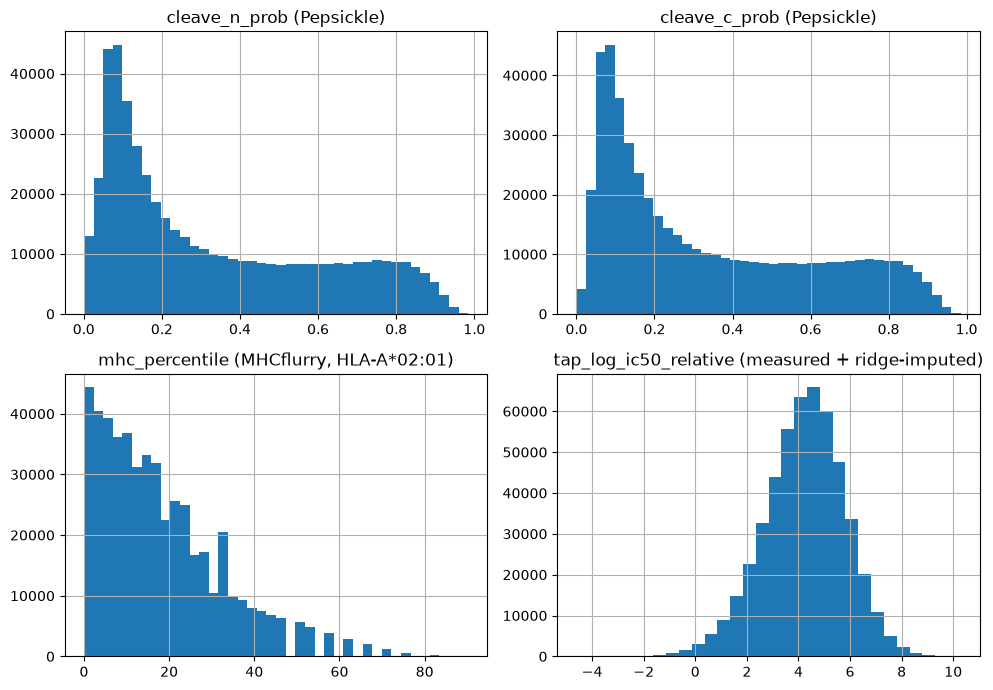

In [7]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(10, 7))
df["cleave_n_prob"].dropna().hist(ax=axes[0, 0], bins=40)
axes[0, 0].set_title("cleave_n_prob (Pepsickle)")
df["cleave_c_prob"].dropna().hist(ax=axes[0, 1], bins=40)
axes[0, 1].set_title("cleave_c_prob (Pepsickle)")
df["mhc_percentile"].hist(ax=axes[1, 0], bins=40)
axes[1, 0].set_title("mhc_percentile (MHCflurry, HLA-A*02:01)")
df["tap_log_ic50_relative"].dropna().hist(ax=axes[1, 1], bins=30)
axes[1, 1].set_title("tap_log_ic50_relative (measured + ridge-imputed)")
fig.tight_layout()
plt.show()

In [8]:
print(pd.crosstab(df["source_domain"], df["split"]))
print("\nprotein clusters spanning >1 split (should be 0):")
overlap = df.groupby("protein_cluster_id")["split"].nunique()
print(int((overlap > 1).sum()))

split               test   train    val
source_domain                          
de_novo             3437   41989   4497
natural_bacterial   9697   71489   8725
natural_human      33159  277539  32597
natural_viral       1635   13794   2055

protein clusters spanning >1 split (should be 0):
0


In [9]:
# Embedding metadata in the parquet (vectors are sidecar, not in-row)
embed_cols = [c for c in ("encoder_model_id", "esm3_model_id", "pooling_recipe", "embedding_cache_key", "has_structure_track") if c in df.columns]
print("encoder columns:", embed_cols)
print(df[embed_cols].nunique().to_string())
print()
print("nulls:")
print(df[embed_cols].isna().sum().to_string())
print()
print(f"unique embedding_cache_key: {df['embedding_cache_key'].nunique():,} / {len(df):,} rows")
print(f"duplicate keys: {df['embedding_cache_key'].duplicated().sum():,}")
print()
print(df[embed_cols].head(8))

encoder columns: ['encoder_model_id', 'pooling_recipe', 'embedding_cache_key', 'has_structure_track']
encoder_model_id            1
pooling_recipe              1
embedding_cache_key    500613
has_structure_track         1

nulls:
encoder_model_id       0
pooling_recipe         0
embedding_cache_key    0
has_structure_track    0

unique embedding_cache_key: 500,613 / 500,613 rows
duplicate keys: 0

      encoder_model_id pooling_recipe       embedding_cache_key  \
0  esm2_t33_650M_UR50D      mean_9mer  7f7818fafc6b3081b3fe073c   
1  esm2_t33_650M_UR50D      mean_9mer  8056244dd0ea04df0825e7ee   
2  esm2_t33_650M_UR50D      mean_9mer  5a932edd6a0827021158907d   
3  esm2_t33_650M_UR50D      mean_9mer  692cedb46f11ac0437af1eb7   
4  esm2_t33_650M_UR50D      mean_9mer  44925e1743453daf782d7d86   
5  esm2_t33_650M_UR50D      mean_9mer  521138663ab32c0835080be7   
6  esm2_t33_650M_UR50D      mean_9mer  0337fe51454b06d4e203ac49   
7  esm2_t33_650M_UR50D      mean_9mer  e729128de4be9dccbbb44a73

In [10]:
# Sidecar embedding caches: e2e_pls memmap + immuno ESM-2 npy (if present)
from pathlib import Path
import numpy as np

REPO_ROOT = PARQUET.parents[2]  # .../results/dataset/file.parquet -> repo

def _find(*parts):
    p = REPO_ROOT.joinpath(*parts)
    return p if p.exists() else None

e2e_dat = _find("results", "e2e_pls", "embedding_cache", "embeddings.dat")
e2e_idx = _find("results", "e2e_pls", "embedding_cache", "embeddings.index.json")
print("=== e2e_pls EmbeddingCache (keyed by embedding_cache_key) ===")
if e2e_dat and e2e_idx:
    import json
    index = json.loads(e2e_idx.read_text())
    n_keys = len(index.get("key_to_row", {}))
    dim = index.get("dim")
    print(f"  {e2e_dat}  {e2e_dat.stat().st_size / 1e6:.1f} MB")
    print(f"  keys={n_keys:,}  dim={dim}  capacity={index.get('capacity')}")
    hit = df["embedding_cache_key"].isin(index.get("key_to_row", {})).mean()
    print(f"  parquet key hit-rate: {hit:.1%}")
else:
    print("  not built yet — parquet has keys only; run training/embed to populate results/e2e_pls/embedding_cache/")

print("\n=== immuno ESM-2 cache (data/processed/esm_cache) ===")
cache_dir = _find("data", "processed", "esm_cache")
if cache_dir is None:
    print("  missing")
else:
    rows = []
    for npy in sorted(cache_dir.glob("*.emb.npy")):
        stem = npy.name.replace(".emb.npy", "")
        arr = np.load(npy, mmap_mode="r")
        idx_path = cache_dir / f"{stem}.index.parquet"
        mask_path = cache_dir / f"{stem}.mask.npy"
        n_idx = len(pd.read_parquet(idx_path)) if idx_path.exists() else None
        mask_shape = np.load(mask_path, mmap_mode="r").shape if mask_path.exists() else None
        rows.append({
            "split": stem.split("__")[0],
            "model": stem.split("__")[1] if "__" in stem else "",
            "emb_shape": tuple(arr.shape),
            "dtype": str(arr.dtype),
            "mb": round(npy.stat().st_size / 1e6, 1),
            "index_rows": n_idx,
            "mask_shape": mask_shape,
            "finite_sample": bool(np.isfinite(arr[0]).all()),
        })
    display(pd.DataFrame(rows))

=== e2e_pls EmbeddingCache (keyed by embedding_cache_key) ===
  not built yet — parquet has keys only; run training/embed to populate results/e2e_pls/embedding_cache/

=== immuno ESM-2 cache (data/processed/esm_cache) ===


,split,model,emb_shape,dtype,mb,index_rows,mask_shape,finite_sample
0,labeled,esm2_t30_150M_UR50D,"(160723, 15, 640)",float16,3085.9,160723,"(160723, 15)",True
1,reference,esm2_t30_150M_UR50D,"(39857, 15, 640)",float16,765.3,39857,"(39857, 15)",True
2,unlabeled,esm2_t30_150M_UR50D,"(75310, 15, 640)",float16,1446.0,75310,"(75310, 15)",True


In [11]:
# Peek one real embedding vector from the immuno cache
cache_dir = REPO_ROOT / "data" / "processed" / "esm_cache"
labeled_npy = cache_dir / "labeled__esm2_t30_150M_UR50D.emb.npy"
labeled_idx = cache_dir / "labeled__esm2_t30_150M_UR50D.index.parquet"
if labeled_npy.exists():
    emb = np.load(labeled_npy, mmap_mode="r")
    idx = pd.read_parquet(labeled_idx)
    print(f"labeled embeddings: {emb.shape} {emb.dtype}")
    print(idx.head(3))
    print("\nfirst window, first 8 dims of residue 0:")
    print(np.asarray(emb[0, 0, :8], dtype=float))
    print(f"per-window L2 norms (first 5): {np.linalg.norm(emb[:5].astype(float), axis=(1, 2)).round(3)}")
else:
    print("labeled immuno cache not found")

labeled embeddings: (160723, 15, 640) float16
               seq
0  MSSFLGKWKLSESHN
1  SSFLGKWKLSESHNF
2  SFLGKWKLSESHNFD

first window, first 8 dims of residue 0:
[-0.21447754  0.02633667  0.28613281 -0.40283203 -0.01951599  0.00969696
  0.02964783 -0.57763672]
per-window L2 norms (first 5): [33.642 33.548 33.588 33.736 33.733]
